In [1]:
# magic commands to reload custom modules
%load_ext autoreload
%autoreload 2

# magic for matplotlib
%matplotlib notebook

import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import uncertainties.unumpy as unp
from uncertainties import ufloat, ufloat_fromstr
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from mapp_tricks.peakfit import PeakFitter, sum_spectras, parse_spectrum_file, sum_spectras_matching_pattern_in_folder, sum_spectra_in_folder
from mapp_tricks.orbitos_utils import ElectrometerDataAnalyzer, BeamData
from mapp_tricks.spectrometer_calibrations import HPGeCalibration, XRayCalibration
from mapp_tricks.cross_section_analysis import GammaPeakAndTargetInfo, DataSource, do_cross_section_analysis, parse_csv, store_csv, get_activity_at_end_of_beam_with_known_cross_section, get_cross_section

from scipy.optimize import curve_fit


In [20]:
calib = XRayCalibration(
    level=1,
)

In [21]:
eff = calib.evaluate_efficiency_at(
    ufloat(40, 1)
)
print(eff)

0.000241+/-0.000011


<IPython.core.display.Javascript object>

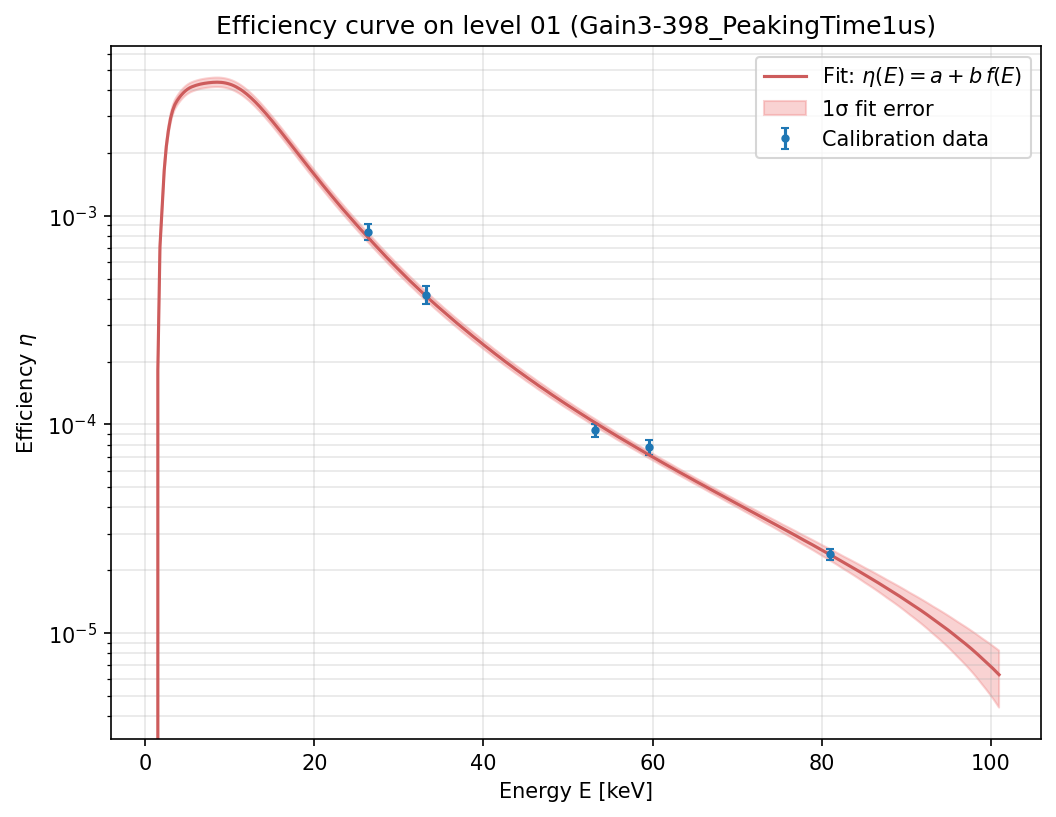

In [32]:
calib.get_plot()

In [2]:
from mapp_tricks.film_analyzer.film_analyzer import  FilmAnalyzer

fa = FilmAnalyzer(
    folder='./data/film_reader_test_data/',
    dpi=1200,
    calibration_key='EBT3_new_METAS_ImageJwRGB',
    plot_downsample=0.5
)


In [3]:
# generate default config and save it to the folder

# config = fa.generate_default_config(
#     default_shape='circular',
#     default_max_dose=10.0,
# )

# fa.save_config(config, fa.folder / 'config.json')

In [4]:
# after generating and editing the config file once, load it like this

config = fa.load_config(fa.folder / 'config.json')

In [6]:
fa.process_all(config, simplify_uncertainty=True)

Processing films:   0%|          | 0/2 [00:00<?, ?file/s]

Processing films:  50%|█████     | 1/2 [00:03<00:03,  3.82s/file]

Saved: DR1mm_01mA_film001.html - ROI mean dose 2.70+/-0.16 Gy (simplify_uncertainty=True)


Processing films: 100%|██████████| 2/2 [00:07<00:00,  3.88s/file]

Saved: DR1mm_03mA_film002.html - ROI mean dose 2.63+/-0.17 Gy (simplify_uncertainty=True)
Summary saved: /home/lars/Nextcloud/Uni/phd/projects/mapp-tricks/playground/data/film_reader_test_data/results/summary.csv (2 entries)
